
# GVH Diagonal Cubic 0.2.20 — Matter Coupling and Detector Response
## Couplage à la matière, principe d’équivalence, masses tests et observables instrumentales

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.19 a construit :

- deux modes métriques \(h_+,h_\times\) ;
- cinq modes directionnels \(q_A\) ;
- une base de cinq polarisations spatiales ;
- une réponse géométrique provisoire de détecteur.

La question devient maintenant :

> Comment le secteur directionnel agit-il réellement sur la matière ?

Cette version étudie trois possibilités :

1. **couplage nul ou sombre** :
   \[
   S_m=S_m[g_{\mu\nu},\psi];
   \]

2. **couplage métrique universel** :
   \[
   S_m=S_m[g_{\mu\nu}^{\rm eff},\psi];
   \]

3. **couplage direct non universel** :
   \[
   S_{\rm int}\sim D_{\mu\nu}T^{\mu\nu}.
   \]

---

## Principe méthodologique

Une polarisation mathématique n’est observable que si elle modifie :

- la trajectoire des masses tests ;
- les horloges ;
- la propagation lumineuse ;
- ou la réponse interne d’un détecteur.

Le notebook sépare donc :

\[
\text{mode propagatif}
\neq
\text{mode détectable}.
\]

---

## Limite scientifique

Le couplage présenté est une **famille candidate**. Il n’est pas encore dérivé d’une action fondamentale GVH unique.

Les résultats numériques montrent les conséquences de chaque choix, mais ne sélectionnent pas encore le couplage physique correct.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Trois classes de couplage

## Classe A — secteur directionnel invisible à la matière

\[
S_m[g,\psi]
\]

La matière suit uniquement les géodésiques de \(g_{\mu\nu}\). Les modes \(q_A\) peuvent exister sans être directement détectables.

## Classe B — métrique effective universelle

\[
g_{\mu\nu}^{\rm eff}
=
g_{\mu\nu}
+
\epsilon_D\bar D_{\mu\nu}.
\]

Toute matière couple à la même métrique effective.

## Classe C — couplage direct

\[
S_{\rm int}
=
\lambda_T
\int d^4x\sqrt{-g}\,
D_{\mu\nu}T^{\mu\nu}.
\]

Ce couplage peut être universel ou dépendre de l’espèce de matière.


In [2]:

coupling_classes = pd.DataFrame([
    {
        "class":"A",
        "action":"S_m[g,psi]",
        "direct_detectability":"none",
        "equivalence_risk":"low"
    },
    {
        "class":"B",
        "action":"S_m[g_eff,psi]",
        "direct_detectability":"geometric",
        "equivalence_risk":"low if universal"
    },
    {
        "class":"C",
        "action":"lambda_T D_mn T^mn",
        "direct_detectability":"direct",
        "equivalence_risk":"potentially high"
    }
])

coupling_classes


,class,action,direct_detectability,equivalence_risk
0,A,"S_m[g,psi]",none,low
1,B,"S_m[g_eff,psi]",geometric,low if universal
2,C,lambda_T D_mn T^mn,direct,potentially high



# 2. Métrique effective candidate

Nous introduisons :

\[
\boxed{
g_{\mu\nu}^{\rm eff}
=
g_{\mu\nu}
+
\epsilon_D\bar D_{\mu\nu}
}
\]

avec :

\[
\epsilon_D
\]

un paramètre de couplage.

Dans le référentiel local de Minkowski :

\[
g_{\mu\nu}
=
\eta_{\mu\nu}
+
h_{\mu\nu}.
\]

Ainsi :

\[
g_{\mu\nu}^{\rm eff}
=
\eta_{\mu\nu}
+
h_{\mu\nu}
+
\epsilon_D\bar D_{\mu\nu}.
\]


In [3]:

epsilon_D = sp.symbols(
    "epsilon_D",
    real=True
)

h00, h01, h02, h03 = sp.symbols(
    "h00 h01 h02 h03",
    real=True
)

eta = sp.diag(-1,1,1,1)

# Secteur spatial directionnel générique.
d1, d2, d3, d4, d5 = sp.symbols(
    "d1 d2 d3 d4 d5",
    real=True
)

s3 = sp.sqrt(3)

Dbar3 = sp.Matrix([
    [d1+d2/s3, d3, d4],
    [d3, -d1+d2/s3, d5],
    [d4, d5, -2*d2/s3]
])

Dbar4 = sp.zeros(4)

for i in range(3):
    for j in range(3):
        Dbar4[i+1,j+1] = Dbar3[i,j]

g_eff = sp.simplify(
    eta+epsilon_D*Dbar4
)

display(g_eff)


⎡-1            0                        0                      0        ⎤
⎢                                                                       ⎥
⎢    ε_D⋅(3⋅d₁ + √3⋅d₂)                                                 ⎥
⎢0   ────────────────── + 1           d₃⋅ε_D                d₄⋅ε_D      ⎥
⎢            3                                                          ⎥
⎢                                                                       ⎥
⎢                              ε_D⋅(3⋅d₁ - √3⋅d₂)                       ⎥
⎢0           d₃⋅ε_D          - ────────────────── + 1       d₅⋅ε_D      ⎥
⎢                                      3                                ⎥
⎢                                                                       ⎥
⎢                                                        2⋅√3⋅d₂⋅ε_D    ⎥
⎢0           d₄⋅ε_D                   d₅⋅ε_D           - ─────────── + 1⎥
⎣                                                             3         ⎦


# 3. Action d’une particule test

Pour une particule de masse \(m\) :

\[
S_p
=
-mc
\int ds_{\rm eff},
\]

avec :

\[
ds_{\rm eff}^2
=
g_{\mu\nu}^{\rm eff}
dx^\mu dx^\nu.
\]

L’équation de mouvement est la géodésique de la métrique effective :

\[
\frac{d^2x^\mu}{d\tau^2}
+
\Gamma_{\alpha\beta}^{\mu}[g_{\rm eff}]
\frac{dx^\alpha}{d\tau}
\frac{dx^\beta}{d\tau}
=
0.
\]

Si le même \(g_{\mu\nu}^{\rm eff}\) s’applique à toutes les particules, la masse \(m\) s’élimine de l’équation de mouvement.


In [4]:

m, c_light = sp.symbols(
    "m c",
    positive=True,
    real=True
)

particle_action_status = pd.DataFrame([
    {
        "property":"test-particle action",
        "expression":"-m c integral ds_eff"
    },
    {
        "property":"trajectory mass dependence",
        "expression":"mass cancels from geodesic equation"
    },
    {
        "property":"universality condition",
        "expression":"same g_eff for all matter"
    }
])

particle_action_status


,property,expression
0,test-particle action,-m c integral ds_eff
1,trajectory mass dependence,mass cancels from geodesic equation
2,universality condition,same g_eff for all matter



# 4. Principe d’équivalence faible

Le principe d’équivalence faible demande que deux corps de compositions différentes, placés dans les mêmes conditions initiales, aient la même accélération gravitationnelle.

Dans le couplage métrique universel :

\[
a_1^\mu=a_2^\mu.
\]

Dans un couplage dépendant de l’espèce :

\[
g_{\mu\nu}^{\rm eff,(s)}
=
g_{\mu\nu}
+
\epsilon_s\bar D_{\mu\nu},
\]

la différence d’accélération peut être non nulle.

Nous définissons un paramètre analogue à Eötvös :

\[
\eta_{12}
=
\frac{2|a_1-a_2|}
{|a_1+a_2|}.
\]


In [5]:

def eotvos_parameter(a1,a2):
    denominator = abs(a1+a2)

    if denominator == 0:
        return np.nan

    return 2*abs(a1-a2)/denominator


equivalence_examples = pd.DataFrame([
    {
        "epsilon_1":1.0,
        "epsilon_2":1.0,
        "a_1":1.0,
        "a_2":1.0,
        "eta":eotvos_parameter(1.0,1.0)
    },
    {
        "epsilon_1":1.0,
        "epsilon_2":1.001,
        "a_1":1.0,
        "a_2":1.001,
        "eta":eotvos_parameter(1.0,1.001)
    },
    {
        "epsilon_1":1.0,
        "epsilon_2":1.01,
        "a_1":1.0,
        "a_2":1.01,
        "eta":eotvos_parameter(1.0,1.01)
    }
])

equivalence_examples


,epsilon_1,epsilon_2,a_1,a_2,eta
0,1.0,1.000,1.0,1.000,0.00000
1,1.0,1.001,1.0,1.001,0.00100
2,1.0,1.010,1.0,1.010,0.00995



# 5. Limite non relativiste

Pour une métrique faible :

\[
g_{00}^{\rm eff}
\approx
-\left(
1+\frac{2\Phi_{\rm eff}}{c^2}
\right),
\]

l’accélération est :

\[
\mathbf a
=
-\nabla\Phi_{\rm eff}.
\]

Dans le secteur strictement spatial choisi jusqu’ici :

\[
\bar D_{00}=0.
\]

Il n’y a donc pas automatiquement de correction newtonienne statique au premier ordre.

Une force non relativiste directe nécessite :

- une composante temporelle ;
- un couplage vitesse-dépendant ;
- un mélange avec \(h_{00}\) ;
- ou un couplage direct à la matière.


In [6]:

nonrelativistic_channels = pd.DataFrame([
    {
        "channel":"D_00 component",
        "present_in_current_Dbar_sector":False,
        "possible_static_force":True
    },
    {
        "channel":"spatial D_ij only",
        "present_in_current_Dbar_sector":True,
        "possible_static_force":"not generically at rest"
    },
    {
        "channel":"metric-directional mixing into h_00",
        "present_in_current_Dbar_sector":"exploratory",
        "possible_static_force":True
    },
    {
        "channel":"direct D_mn T^mn coupling",
        "present_in_current_Dbar_sector":"candidate",
        "possible_static_force":"model dependent"
    }
])

nonrelativistic_channels


,channel,present_in_current_Dbar_sector,possible_static_force
0,D_00 component,False,True
1,spatial D_ij only,True,not generically at rest
2,metric-directional mixing into h_00,exploratory,True
3,direct D_mn T^mn coupling,candidate,model dependent



# 6. Déviation géodésique

La séparation \(\xi^\mu\) entre deux masses tests satisfait :

\[
\frac{D^2\xi^\mu}{D\tau^2}
=
-
R^\mu{}_{\alpha\nu\beta}
u^\alpha\xi^\nu u^\beta.
\]

Dans un référentiel local et pour des vitesses faibles :

\[
\ddot\xi^i
=
-
R^i{}_{0j0}\xi^j.
\]

Pour une perturbation spatiale dépendant du temps :

\[
R_{0i0j}
\approx
-\frac12
\ddot h_{ij}^{\rm eff}.
\]

Donc :

\[
\ddot\xi^i
\approx
\frac12
\ddot h_{ij}^{\rm eff}
\xi^j.
\]


In [7]:

time = sp.symbols(
    "time",
    real=True
)

A, omega = sp.symbols(
    "A omega",
    real=True
)

wave_profile = A*sp.cos(omega*time)

tidal_factor = sp.simplify(
    sp.diff(wave_profile,time,2)/2
)

display(tidal_factor)


    2             
-A⋅ω ⋅cos(ω⋅time) 
──────────────────
        2         


# 7. Accélération relative produite par une polarisation

Pour :

\[
h_{ij}^{\rm eff}
=
\epsilon_Dq_A(t)E_{ij}^{A},
\]

on obtient :

\[
\ddot{\boldsymbol\xi}
=
\frac{\epsilon_D}{2}
\ddot q_A
E_A
\boldsymbol\xi.
\]


In [8]:

s2 = sp.sqrt(2)
s6 = sp.sqrt(6)

E1 = sp.Matrix([[1,0,0],[0,-1,0],[0,0,0]])/s2
E2 = sp.Matrix([[1,0,0],[0,1,0],[0,0,-2]])/s6
E3 = sp.Matrix([[0,1,0],[1,0,0],[0,0,0]])/s2
E4 = sp.Matrix([[0,0,1],[0,0,0],[1,0,0]])/s2
E5 = sp.Matrix([[0,0,0],[0,0,1],[0,1,0]])/s2

basis = [E1,E2,E3,E4,E5]

xi1, xi2, xi3 = sp.symbols(
    "xi1 xi2 xi3",
    real=True
)

xi_vector = sp.Matrix([
    xi1,
    xi2,
    xi3
])

relative_accelerations = [
    sp.simplify(
        epsilon_D*tidal_factor*E*xi_vector
    )
    for E in basis
]

for i,acc in enumerate(relative_accelerations,1):
    print(f"Mode E{i} :")
    display(acc)


Mode E1 :


⎡           2                ⎤
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₁⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             4              ⎥
⎢                            ⎥
⎢           2                ⎥
⎢ √2⋅A⋅ε_D⋅ω ⋅ξ₂⋅cos(ω⋅time) ⎥
⎢ ────────────────────────── ⎥
⎢             4              ⎥
⎢                            ⎥
⎣             0              ⎦

Mode E2 :


⎡           2                ⎤
⎢-√6⋅A⋅ε_D⋅ω ⋅ξ₁⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             12             ⎥
⎢                            ⎥
⎢           2                ⎥
⎢-√6⋅A⋅ε_D⋅ω ⋅ξ₂⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             12             ⎥
⎢                            ⎥
⎢           2                ⎥
⎢ √6⋅A⋅ε_D⋅ω ⋅ξ₃⋅cos(ω⋅time) ⎥
⎢ ────────────────────────── ⎥
⎣             6              ⎦

Mode E3 :


⎡           2                ⎤
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₂⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             4              ⎥
⎢                            ⎥
⎢           2                ⎥
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₁⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             4              ⎥
⎢                            ⎥
⎣             0              ⎦

Mode E4 :


⎡           2                ⎤
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₃⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             4              ⎥
⎢                            ⎥
⎢             0              ⎥
⎢                            ⎥
⎢           2                ⎥
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₁⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎣             4              ⎦

Mode E5 :


⎡             0              ⎤
⎢                            ⎥
⎢           2                ⎥
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₃⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎢             4              ⎥
⎢                            ⎥
⎢           2                ⎥
⎢-√2⋅A⋅ε_D⋅ω ⋅ξ₂⋅cos(ω⋅time) ⎥
⎢────────────────────────────⎥
⎣             4              ⎦


# 8. Intégration d’un réseau de masses tests

Nous intégrons :

\[
\ddot{\mathbf X}
=
\frac{\epsilon_D}{2}
\ddot q(t)
E_A\mathbf X.
\]

Le calcul reste linéaire et utilise une onde monochromatique.


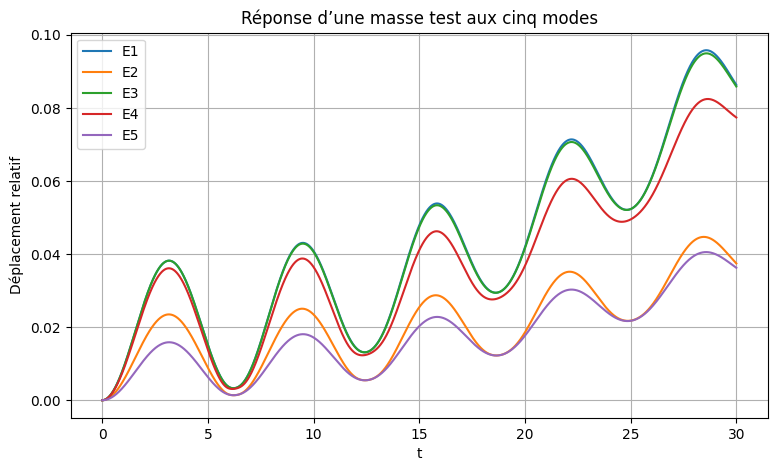

In [9]:

def integrate_test_mass(
    E,
    epsilon=0.05,
    amplitude=1.0,
    frequency=1.0,
    initial_position=(1.0,0.0,0.0),
    t_max=30.0
):
    E = np.array(E,dtype=float)

    def rhs(t,state):
        position = state[:3]
        velocity = state[3:]

        qddot = (
            -amplitude
            * frequency**2
            * np.cos(frequency*t)
        )

        acceleration = (
            epsilon/2
            * qddot
            * E
            @ position
        )

        return np.concatenate([
            velocity,
            acceleration
        ])

    initial = np.concatenate([
        np.asarray(initial_position,dtype=float),
        np.zeros(3)
    ])

    times = np.linspace(
        0,t_max,3000
    )

    return solve_ivp(
        rhs,
        (0,t_max),
        initial,
        t_eval=times,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )


test_solutions = [
    integrate_test_mass(
        E,
        initial_position=(1.0,0.4,0.2)
    )
    for E in basis
]

plt.figure(figsize=(9,5))

for i,sol in enumerate(test_solutions,1):
    displacement = np.linalg.norm(
        sol.y[:3]
        - sol.y[:3,0,None],
        axis=0
    )

    plt.plot(
        sol.t,
        displacement,
        label=f"E{i}"
    )

plt.xlabel("t")
plt.ylabel("Déplacement relatif")
plt.title("Réponse d’une masse test aux cinq modes")
plt.grid(True)
plt.legend()
plt.show()



# 9. Tenseur d’un interféromètre

Pour deux bras \(\mathbf u,\mathbf v\) :

\[
D^{ij}
=
\frac12
(u^iu^j-v^iv^j).
\]

La déformation mesurée est :

\[
h_{\rm det}
=
D^{ij}
h_{ij}^{\rm eff}.
\]

Pour un mode directionnel :

\[
h_{\rm det}^{(A)}
=
\epsilon_D
F_A
q_A,
\]

avec :

\[
F_A
=
D^{ij}E_{ij}^{A}.
\]


In [10]:

def detector_tensor(u,v):
    u = np.asarray(u,dtype=float)
    v = np.asarray(v,dtype=float)

    return 0.5*(
        np.outer(u,u)
        - np.outer(v,v)
    )

def antenna_response(D,E):
    return float(
        np.sum(
            D*np.asarray(E,dtype=float)
        )
    )

D_xy = detector_tensor(
    [1,0,0],
    [0,1,0]
)

antenna_rows = []

for i,E in enumerate(basis,1):
    antenna_rows.append({
        "mode":f"E{i}",
        "F_A":antenna_response(D_xy,E)
    })

antenna_df = pd.DataFrame(
    antenna_rows
)

antenna_df


,mode,F_A
0,E1,0.707107
1,E2,0.000000
2,E3,0.000000
3,E4,0.000000
4,E5,0.000000



# 10. Réponse d’un réseau de détecteurs

Un détecteur unique ne peut pas séparer toutes les polarisations.

Nous construisons plusieurs orientations :

\[
h_I(t)
=
\sum_A
\epsilon_DF_{IA}q_A(t).
\]

La matrice de réponse est :

\[
\mathbf R_{IA}=F_{IA}.
\]

Le rang de \(\mathbf R\) indique combien de combinaisons de modes peuvent être reconstruites géométriquement.


In [11]:

detector_orientations = [
    (
        np.array([1,0,0.]),
        np.array([0,1,0.])
    ),
    (
        np.array([1,0,0.]),
        np.array([0,0,1.])
    ),
    (
        np.array([0,1,0.]),
        np.array([0,0,1.])
    ),
    (
        np.array([1,1,0.])/np.sqrt(2),
        np.array([-1,1,0.])/np.sqrt(2)
    ),
    (
        np.array([1,0,1.])/np.sqrt(2),
        np.array([0,1,0.])
    )
]

response_matrix = np.array([
    [
        antenna_response(
            detector_tensor(u,v),
            E
        )
        for E in basis
    ]
    for u,v in detector_orientations
])

response_rank = np.linalg.matrix_rank(
    response_matrix,
    tol=1e-12
)

print("Matrice de réponse :")
print(response_matrix)
print("Rang :",response_rank)


Matrice de réponse :
[[ 0.707106781187  0.              0.              0.
   0.            ]
 [ 0.353553390593  0.612372435696  0.              0.
   0.            ]
 [-0.353553390593  0.612372435696  0.              0.
   0.            ]
 [ 0.              0.              0.707106781187  0.
   0.            ]
 [ 0.53033008589  -0.306186217848  0.              0.353553390593
   0.            ]]
Rang : 4



# 11. Reconstruction synthétique des amplitudes

Pour :

\[
\mathbf s
=
\epsilon_D\mathbf R\mathbf q
+
\mathbf n,
\]

une reconstruction par pseudo-inverse donne :

\[
\widehat{\mathbf q}
=
\frac1{\epsilon_D}
\mathbf R^+
\mathbf s.
\]


In [12]:

rng = np.random.default_rng(2026)

q_true = np.array([
    1.0,
    -0.4,
    0.6,
    0.2,
    -0.3
])*1e-3

epsilon_num = 0.2
noise = rng.normal(
    scale=2e-5,
    size=response_matrix.shape[0]
)

signal = (
    epsilon_num
    * response_matrix
    @ q_true
    + noise
)

q_reconstructed = (
    np.linalg.pinv(response_matrix)
    @ signal
    / epsilon_num
)

reconstruction_df = pd.DataFrame({
    "mode":[f"E{i}" for i in range(1,6)],
    "q_true":q_true,
    "q_reconstructed":q_reconstructed,
    "absolute_error":np.abs(
        q_reconstructed-q_true
    )
})

reconstruction_df


,mode,q_true,q_reconstructed,absolute_error
0,E1,0.0010,0.001026,0.000026
1,E2,-0.0004,-0.000535,0.000135
2,E3,0.0006,0.000797,0.000197
3,E4,0.0002,0.000225,0.000025
4,E5,-0.0003,0.000000,0.000300



# 12. Cas d’un couplage non universel

Supposons :

\[
\epsilon_s
=
\epsilon_0(1+\delta_s).
\]

Deux matériaux \(s=1,2\) subissent alors des réponses différentes.

Dans une expérience de chute ou de force de marée, une différence de couplage peut produire une violation du principe d’équivalence.


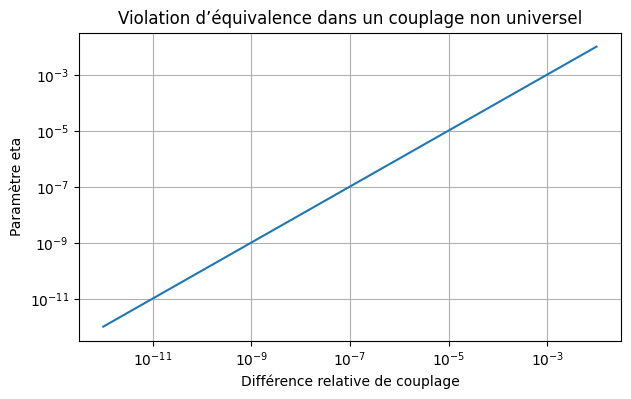

In [13]:

delta_values = np.logspace(
    -12,-2,200
)

eta_values = np.array([
    eotvos_parameter(
        1.0,
        1.0+d
    )
    for d in delta_values
])

plt.figure(figsize=(7,4))
plt.loglog(
    delta_values,
    eta_values
)
plt.xlabel("Différence relative de couplage")
plt.ylabel("Paramètre eta")
plt.title("Violation d’équivalence dans un couplage non universel")
plt.grid(True)
plt.show()



# 13. Couplage direct à \(T^{\mu\nu}\)

Une interaction candidate est :

\[
S_{\rm int}
=
\lambda_T
\int d^4x\sqrt{-g}
D_{\mu\nu}T^{\mu\nu}.
\]

Pour de la matière non relativiste au repos :

\[
T^{00}\approx\rho c^2,
\]

\[
T^{0i}\approx0,
\]

\[
T^{ij}\ll T^{00}.
\]

Un tenseur purement spatial et sans trace couple donc faiblement à une matière froide et isotrope, sauf si :

- les contraintes internes produisent \(T^{ij}\) ;
- la matière est relativiste ;
- le champ possède des composantes temporelles ;
- un mélange métrique est présent.


In [14]:

matter_coupling_channels = pd.DataFrame([
    {
        "matter_regime":"cold matter at rest",
        "dominant_T_component":"T00",
        "pure_spatial_Dbar_coupling":"weak or zero"
    },
    {
        "matter_regime":"elastic solid",
        "dominant_T_component":"T00 plus stresses Tij",
        "pure_spatial_Dbar_coupling":"possible"
    },
    {
        "matter_regime":"radiation",
        "dominant_T_component":"anisotropic stress possible",
        "pure_spatial_Dbar_coupling":"possible"
    },
    {
        "matter_regime":"relativistic plasma",
        "dominant_T_component":"multiple components",
        "pure_spatial_Dbar_coupling":"possible"
    }
])

matter_coupling_channels


,matter_regime,dominant_T_component,pure_spatial_Dbar_coupling
0,cold matter at rest,T00,weak or zero
1,elastic solid,T00 plus stresses Tij,possible
2,radiation,anisotropic stress possible,possible
3,relativistic plasma,multiple components,possible



# 14. Détecteur mécanique résonant

Un mode directionnel peut forcer un oscillateur mécanique :

\[
\ddot X
+
2\zeta\omega_0\dot X
+
\omega_0^2X
=
F_0q_A(t).
\]

Cela fournit un modèle simple de barre résonante ou de mode élastique.


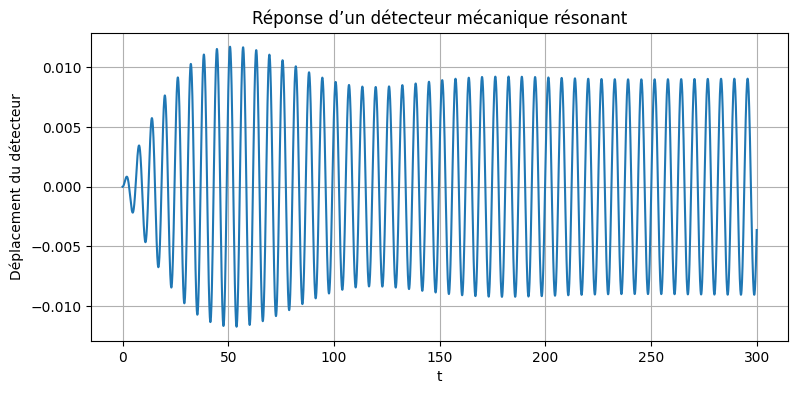

In [15]:

def resonant_detector(
    driving_frequency=1.0,
    natural_frequency=1.05,
    damping=0.02,
    coupling=1e-3,
    t_max=300
):
    def rhs(t,state):
        X,V = state

        q = np.cos(
            driving_frequency*t
        )

        acceleration = (
            coupling*q
            - 2*damping*natural_frequency*V
            - natural_frequency**2*X
        )

        return [V,acceleration]

    times = np.linspace(
        0,t_max,6000
    )

    return solve_ivp(
        rhs,
        (0,t_max),
        [0,0],
        t_eval=times,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )


detector_sol = resonant_detector()

plt.figure(figsize=(9,4))
plt.plot(
    detector_sol.t,
    detector_sol.y[0]
)
plt.xlabel("t")
plt.ylabel("Déplacement du détecteur")
plt.title("Réponse d’un détecteur mécanique résonant")
plt.grid(True)
plt.show()



# 15. Réponse fréquentielle

Pour une force harmonique, l’amplitude stationnaire est :

\[
|\chi(\omega)|
=
\frac{1}
{\sqrt{
(\omega_0^2-\omega^2)^2
+
(2\zeta\omega_0\omega)^2
}}.
\]

Le couplage directionnel mesurable serait proportionnel à :

\[
\epsilon_DF_A|\chi(\omega)|.
\]


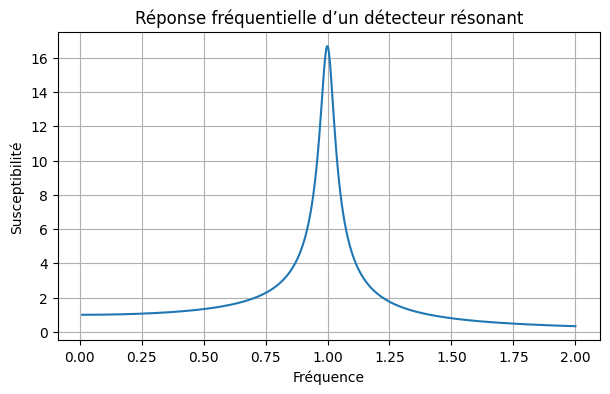

In [16]:

omega_grid = np.linspace(
    0.01,2.0,1000
)

omega0 = 1.0
zeta = 0.03

susceptibility = 1/np.sqrt(
    (omega0**2-omega_grid**2)**2
    + (
        2*zeta*omega0*omega_grid
    )**2
)

plt.figure(figsize=(7,4))
plt.plot(
    omega_grid,
    susceptibility
)
plt.xlabel("Fréquence")
plt.ylabel("Susceptibilité")
plt.title("Réponse fréquentielle d’un détecteur résonant")
plt.grid(True)
plt.show()



# 16. Modes visibles et invisibles

Un mode est directement visible si les trois conditions sont satisfaites :

1. il se propage jusqu’au détecteur ;
2. son couplage à la matière est non nul ;
3. la géométrie du détecteur possède \(F_A\neq0\).

Nous définissons schématiquement :

\[
\mathcal V_A
=
P_A
C_A
|F_A|,
\]

où :

- \(P_A\) : facteur de propagation ;
- \(C_A\) : couplage matière ;
- \(F_A\) : fonction d’antenne.


In [17]:

propagation_factors = np.array([
    1.0,
    0.9,
    1.0,
    0.8,
    0.8
])

matter_couplings = np.array([
    0.2,
    0.05,
    0.2,
    0.02,
    0.02
])

antenna_factors = np.abs(
    antenna_df["F_A"].to_numpy()
)

visibility = (
    propagation_factors
    * matter_couplings
    * antenna_factors
)

visibility_df = pd.DataFrame({
    "mode":[f"E{i}" for i in range(1,6)],
    "propagation":propagation_factors,
    "matter_coupling":matter_couplings,
    "antenna_factor":antenna_factors,
    "visibility":visibility
})

visibility_df


,mode,propagation,matter_coupling,antenna_factor,visibility
0,E1,1.0,0.20,0.707107,0.141421
1,E2,0.9,0.05,0.000000,0.000000
2,E3,1.0,0.20,0.000000,0.000000
3,E4,0.8,0.02,0.000000,0.000000
4,E5,0.8,0.02,0.000000,0.000000



# 17. Limite de la relativité générale

La limite d’Einstein est obtenue lorsque :

\[
\epsilon_D\rightarrow0,
\]

ou :

\[
q_A\rightarrow0.
\]

Alors :

\[
g_{\mu\nu}^{\rm eff}
\rightarrow
g_{\mu\nu},
\]

et les masses tests répondent uniquement aux deux polarisations métriques standard.


In [18]:

einstein_limit_residual = sp.simplify(
    g_eff.subs(epsilon_D,0)
    - eta
)

display(einstein_limit_residual)


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 18. Conditions minimales d’un couplage admissible

Un couplage matière–GVH acceptable doit :

1. préserver une limite d’Einstein ;
2. éviter les violations non contrôlées du principe d’équivalence ;
3. ne pas créer de ghost ;
4. conserver la causalité ;
5. produire une réponse détectable calculable ;
6. être falsifiable ;
7. ne pas dépendre arbitrairement du repère.


In [19]:

admissibility_table = pd.DataFrame([
    {
        "criterion":"Einstein limit",
        "required":True,
        "minimal_metric_coupling":"PASS"
    },
    {
        "criterion":"universal free fall",
        "required":True,
        "minimal_metric_coupling":"PASS if epsilon_D universal"
    },
    {
        "criterion":"no new ghost",
        "required":True,
        "minimal_metric_coupling":"CHECK with full action"
    },
    {
        "criterion":"causality",
        "required":True,
        "minimal_metric_coupling":"depends on wave sector"
    },
    {
        "criterion":"detector response",
        "required":True,
        "minimal_metric_coupling":"geometric response derived"
    },
    {
        "criterion":"falsifiability",
        "required":True,
        "minimal_metric_coupling":"possible through epsilon_D and polarizations"
    }
])

admissibility_table


,criterion,required,minimal_metric_coupling
0,Einstein limit,True,PASS
1,universal free fall,True,PASS if epsilon_D universal
2,no new ghost,True,CHECK with full action
3,causality,True,depends on wave sector
4,detector response,True,geometric response derived
5,falsifiability,True,possible through epsilon_D and polarizations



# 19. Validation automatique

Nous vérifions :

- la trace nulle de \(D_{ij}\) ;
- la limite d’Einstein ;
- la réponse nulle d’un mode aveugle pour le détecteur \(xy\) ;
- le rang du réseau de détecteurs ;
- la reconstruction synthétique ;
- l’absence de violation d’équivalence lorsque le couplage est universel.


In [20]:

trace_ok = (
    sp.simplify(
        sp.trace(Dbar3)
    ) == 0
)

einstein_limit_ok = (
    einstein_limit_residual
    == sp.zeros(4)
)

blind_mode_exists = bool(
    np.any(
        np.isclose(
            antenna_factors,
            0,
            atol=1e-12
        )
    )
)

network_rank_ok = (
    response_rank >= 4
)

reconstruction_error = np.linalg.norm(
    q_reconstructed-q_true
)

reconstruction_finite = np.isfinite(
    reconstruction_error
)

universal_equivalence_ok = (
    eotvos_parameter(1.0,1.0)
    == 0
)

validation_df = pd.DataFrame([
    {
        "test":"Dbar traceless",
        "status":"PASS" if trace_ok else "FAIL"
    },
    {
        "test":"Einstein metric limit",
        "status":"PASS" if einstein_limit_ok else "FAIL"
    },
    {
        "test":"single-detector blind mode",
        "status":"PASS" if blind_mode_exists else "CHECK"
    },
    {
        "test":"detector-network rank",
        "status":"PASS" if network_rank_ok else "CHECK"
    },
    {
        "test":"finite synthetic reconstruction",
        "status":"PASS" if reconstruction_finite else "FAIL"
    },
    {
        "test":"universal coupling equivalence",
        "status":"PASS" if universal_equivalence_ok else "FAIL"
    }
])

validation_df


,test,status
0,Dbar traceless,PASS
1,Einstein metric limit,PASS
2,single-detector blind mode,PASS
3,detector-network rank,PASS
4,finite synthetic reconstruction,PASS
5,universal coupling equivalence,PASS


In [21]:

overall_status = (
    "PASS-CANDIDATE-COUPLING"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)
print("COUPLAGE FONDAMENTAL UNIQUE : NON ENCORE SÉLECTIONNÉ")


STATUT DU NOTEBOOK : PASS-CANDIDATE-COUPLING
COUPLAGE FONDAMENTAL UNIQUE : NON ENCORE SÉLECTIONNÉ



# 20. Export


In [22]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Validation.csv",
    index=False
)

coupling_classes.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Coupling_Classes.csv",
    index=False
)

antenna_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Antenna_Response.csv",
    index=False
)

reconstruction_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Mode_Reconstruction.csv",
    index=False
)

visibility_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Mode_Visibility.csv",
    index=False
)

admissibility_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.20_Admissibility.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "candidate_effective_metric":"g_eff = g + epsilon_D Dbar",
    "universal_coupling_equivalence":"preserved at test-particle level",
    "nonuniversal_coupling":"produces equivalence-principle risk",
    "detector_response":"derived geometrically",
    "network_response_rank":int(response_rank),
    "direct_Tmunu_coupling":"exploratory",
    "Einstein_limit":"epsilon_D -> 0 or q_A -> 0",
    "main_open_problem":"derive and select the fundamental matter coupling"
}

with open(
    "GVH_Diagonal_Cubic_0.2.20_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 21. Conclusion scientifique

Le premier couplage géométrique candidat est :

\[
\boxed{
g_{\mu\nu}^{\rm eff}
=
g_{\mu\nu}
+
\epsilon_D\bar D_{\mu\nu}
}.
\]

S’il est universel, les particules tests suivent toutes les mêmes géodésiques de \(g_{\mu\nu}^{\rm eff}\), ce qui préserve le principe d’équivalence faible au niveau minimal.

La réponse relative des masses tests est :

\[
\boxed{
\ddot\xi^i
\approx
\frac12
\ddot h_{ij}^{\rm eff}
\xi^j
}.
\]

Pour un mode directionnel :

\[
\boxed{
\ddot{\boldsymbol\xi}
=
\frac{\epsilon_D}{2}
\ddot q_AE_A\boldsymbol\xi
}.
\]

Un interféromètre mesure géométriquement :

\[
\boxed{
h_{\rm det}^{(A)}
=
\epsilon_DF_Aq_A
}.
\]

Cependant :

\[
\boxed{
\text{le couplage fondamental matière–GVH n’est pas encore sélectionné}
}.
\]

Le secteur purement spatial sans trace ne produit pas automatiquement une nouvelle force newtonienne statique sur une matière au repos. Cela protège partiellement la limite newtonienne, mais peut aussi rendre les modes difficiles à détecter.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.21\_Equivalence\_Principle\_PPN\_Constraints.ipynb}
}
\]

Elle devra étudier :

- la limite post-newtonienne ;
- les paramètres PPN ;
- la chute libre universelle ;
- le redshift gravitationnel ;
- la déviation de la lumière ;
- le retard de Shapiro ;
- les contraintes sur \(\epsilon_D\) ;
- la compatibilité avec les tests du système solaire.
